### Healthcare Test Result Prediction using Machine Learning

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

In [50]:
df = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\data science\healthcare_dataset.csv (1)\healthcare_dataset.csv")
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [53]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

### Feature Engineering

In [54]:
# Convert to datetime
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Create new feature
df['Stay Days'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df['Age_Billing'] = df['Age'] * df['Billing Amount']
df['Stay_Billing'] = df['Stay Days'] * df['Billing Amount']
df['Age_Stay'] = df['Age'] * df['Stay Days']

In [55]:
df['Age Group'] = pd.cut(df['Age'],
bins=[0,18,40,60,100],
labels=['Child','Young','Adult','Senior'])

In [56]:
df.select_dtypes(include=['object']).columns

Index(['Name', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor',
       'Hospital', 'Insurance Provider', 'Admission Type', 'Medication',
       'Test Results'],
      dtype='object')

In [58]:
X = df.drop('Test Results', axis=1)
y = df['Test Results']

KeyError: "['Test Results'] not found in axis"

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train with multiple models

In [ ]:

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(max_depth=10)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
gb = GradientBoostingClassifier()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

ValueError: could not convert string to float: 'Aetna'

In [29]:
from sklearn.metrics import accuracy_score, classification_report

models = [lr, dt, rf, gb]
names = ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]

for model, name in zip(models, names):
    pred = model.predict(X_test)
    print(name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))
    print("------")

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Accuracy: 0.3291891891891892
              precision    recall  f1-score   support

           0       0.33      0.38      0.35      3754
           1       0.32      0.33      0.32      3617
           2       0.34      0.28      0.31      3729

    accuracy                           0.33     11100
   macro avg       0.33      0.33      0.33     11100
weighted avg       0.33      0.33      0.33     11100

------
Decision Tree
Accuracy: 0.3893693693693694
              precision    recall  f1-score   support

           0       0.39      0.39      0.39      3754
           1       0.38      0.39      0.39      3617
           2       0.39      0.39      0.39      3729

    accuracy                           0.39     11100
   macro avg       0.39      0.39      0.39     11100
weighted avg       0.39      0.39      0.39     11100

------
Random Forest
Accuracy: 0.42162162162162165
              precision    recall  f1-score   support

           0       0.43      0.43

In [30]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(rf, X_train, y_train, cv=5)
print("Cross Validation Score:", score.mean())

0.43614414414414415


In [ ]:
importance = rf.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importance)), importance)
plt.title("Feature Importance")
plt.show()

In [32]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

NameError: name 'cm' is not defined

In [81]:
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

Billing Amount        0.191669
Room Number           0.181021
Age                   0.148554
Stay Days             0.129295
Blood Type            0.081337
Medical Condition     0.071947
Insurance Provider    0.064414
Medication            0.064282
Admission Type        0.042688
Gender                0.024793
dtype: float64


### Exploratory Data Analysis

In [ ]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

In [ ]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

In [ ]:
sns.countplot(x='Medical Condition', hue='Test Results', data=df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
sns.boxplot(df['Billing Amount'])
plt.show()

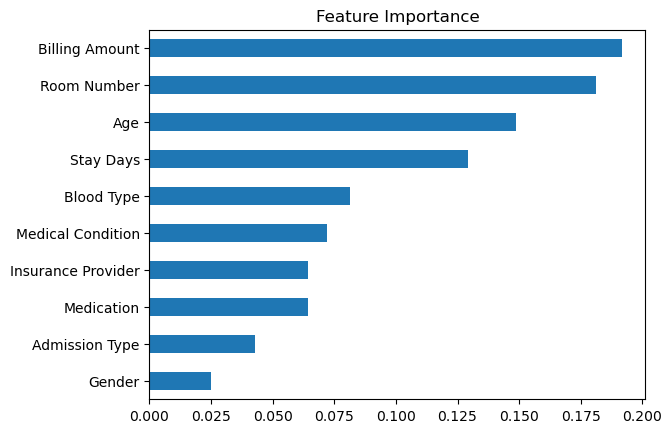

In [90]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()